In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
PALETTE = sns.color_palette("Set2")

In [ ]:
students   = pd.read_csv("students.csv")
colleges   = pd.read_csv("colleges.csv")
events     = pd.read_csv("events.csv")
projects   = pd.read_csv("projects.csv")
research   = pd.read_csv("research.csv")
login      = pd.read_csv("Login_Credentials.csv")

In [ ]:
print("=" * 55)
print("  UNLOX — EDA SUMMARY")
print("=" * 55)
for name, df in [("students", students), ("colleges", colleges),
                 ("events", events), ("projects", projects),
                 ("research", research), ("login", login)]:
    print(f"\n📂 {name.upper()} — {df.shape[0]} rows × {df.shape[1]} cols")
    print(df.dtypes.to_string())

  UNLOX — EDA SUMMARY

📂 STUDENTS — 200 rows × 5 cols
student_id      object
student_name    object
department      object
year             int64
college_id      object

📂 COLLEGES — 15 rows × 4 cols
college_id      object
college_name    object
city            object
state           object

📂 EVENTS — 80 rows × 5 cols
event_id        object
event_name      object
event_type      object
participants     int64
college_id      object

📂 PROJECTS — 120 rows × 5 cols
project_id       object
project_title    object
student_id       object
research_id      object
likes             int64

📂 RESEARCH — 100 rows × 5 cols
research_id       object
research_title    object
research_field    object
year               int64
college_id        object

📂 LOGIN — 100 rows × 9 cols
student_id       object
college_name     object
username         object
email            object
password_hash    object
department       object
year              int64
contact_phone     int64
enrollment_no    object


In [ ]:
print("\n\n" + "=" * 55)
print("  MISSING VALUE REPORT")
print("=" * 55)
for name, df in [("students", students), ("colleges", colleges),
                 ("events", events), ("projects", projects),
                 ("research", research), ("login", login)]:
    missing = df.isnull().sum()
    print(f"\n{name.upper()}:")
    print(missing[missing > 0] if missing.any() else "  ✅ No missing values")

print("\n\n" + "=" * 55)
print("  DESCRIPTIVE STATISTICS")
print("=" * 55)
print("\nSTUDENTS:\n",  students.describe(include="all").T)
print("\nEVENTS:\n",    events.describe(include="all").T)
print("\nPROJECTS:\n",  projects.describe(include="all").T)
print("\nRESEARCH:\n",  research.describe(include="all").T)



  MISSING VALUE REPORT

STUDENTS:
  ✅ No missing values

COLLEGES:
  ✅ No missing values

EVENTS:
  ✅ No missing values

PROJECTS:
  ✅ No missing values

RESEARCH:
  ✅ No missing values

LOGIN:
  ✅ No missing values


  DESCRIPTIVE STATISTICS

STUDENTS:
               count unique         top freq   mean       std  min  25%  50%  \
student_id      200    200        S001    1    NaN       NaN  NaN  NaN  NaN   
student_name    200    200   Student_1    1    NaN       NaN  NaN  NaN  NaN   
department      200      7  Mechanical   40    NaN       NaN  NaN  NaN  NaN   
year          200.0    NaN         NaN  NaN  2.495  1.116336  1.0  1.0  3.0   
college_id      200     15        C003   24    NaN       NaN  NaN  NaN  NaN   

              75%  max  
student_id    NaN  NaN  
student_name  NaN  NaN  
department    NaN  NaN  
year          3.0  4.0  
college_id    NaN  NaN  

EVENTS:
              count unique           top freq      mean         std   min  \
event_id        80     80       

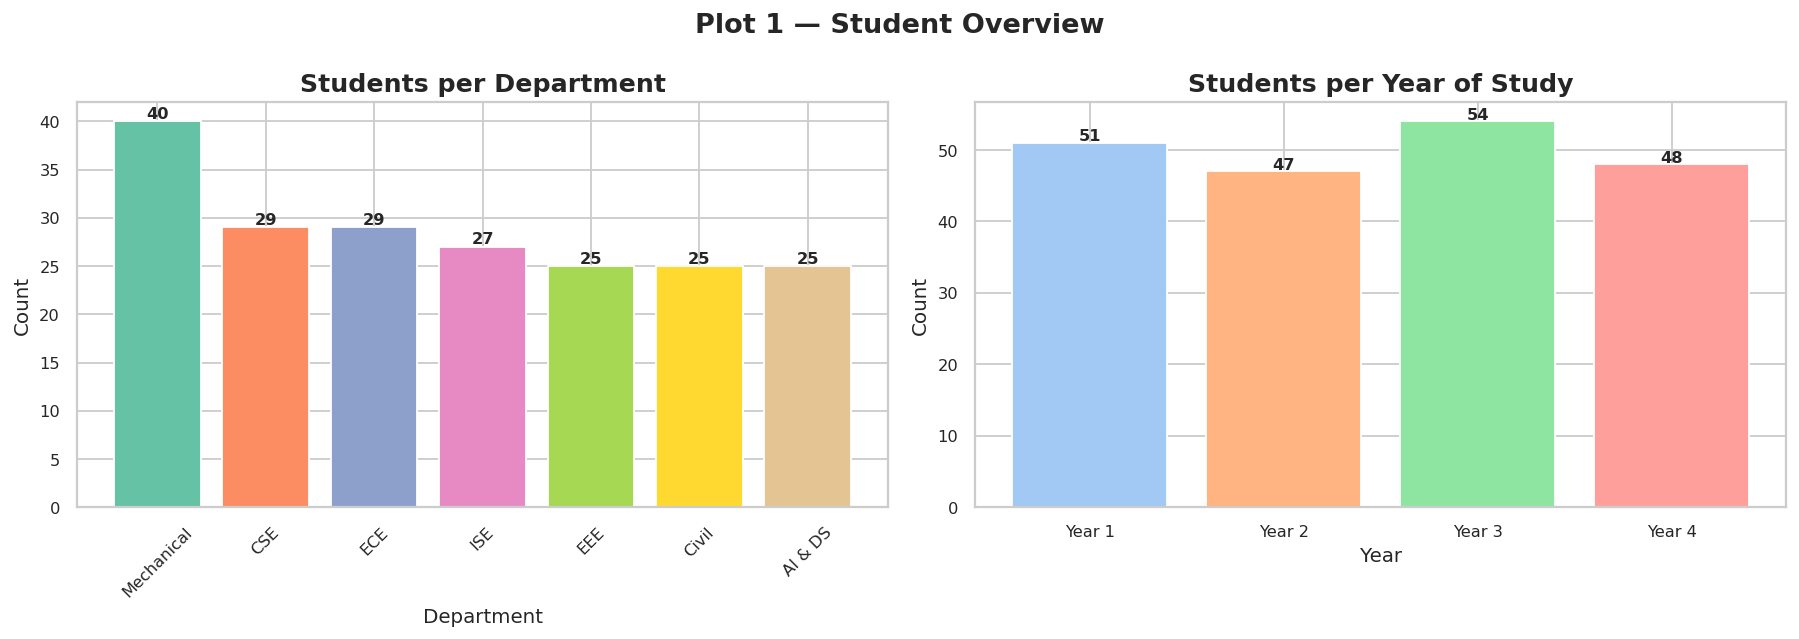

✅ Saved: plot1_student_overview.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 1 — Student Overview", fontsize=15, fontweight="bold")

dept_counts = students["department"].value_counts()
axes[0].bar(dept_counts.index, dept_counts.values,
            color=sns.color_palette("Set2", len(dept_counts)))
axes[0].set_title("Students per Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(dept_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9, fontweight="bold")

year_counts = students["year"].value_counts().sort_index()
axes[1].bar([f"Year {y}" for y in year_counts.index], year_counts.values,
            color=sns.color_palette("pastel", len(year_counts)))
axes[1].set_title("Students per Year of Study")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")
for i, v in enumerate(year_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("plot1_student_overview.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot1_student_overview.png")

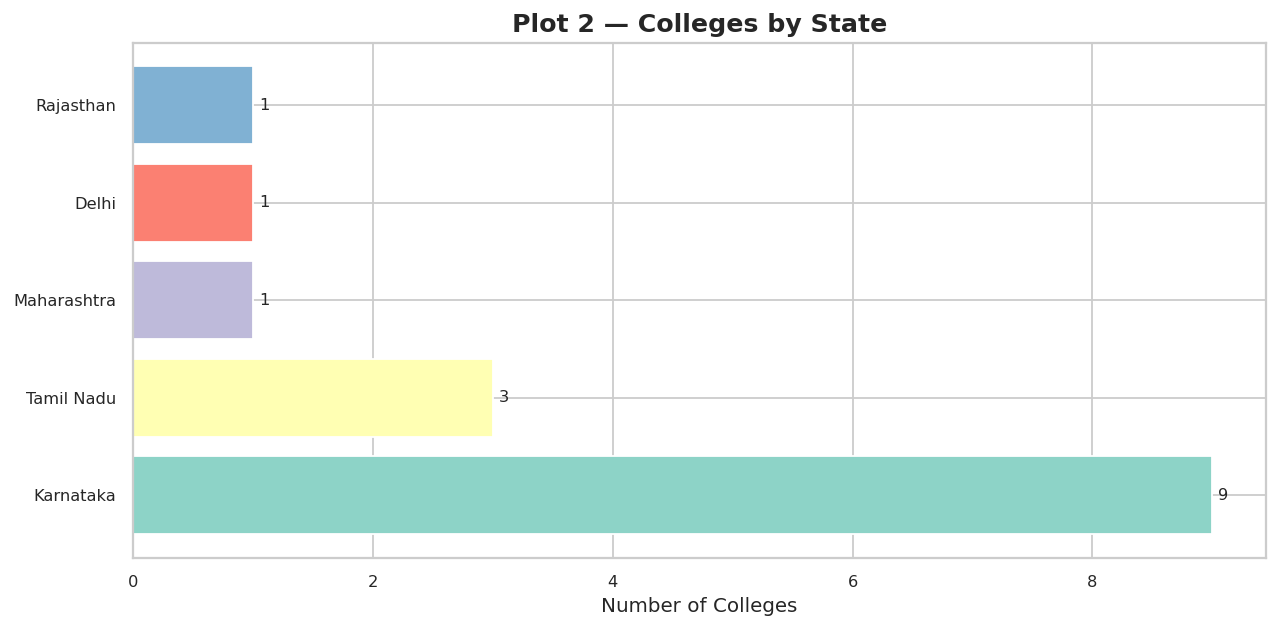

✅ Saved: plot2_colleges_by_state.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
state_counts = colleges["state"].value_counts()
bars = ax.barh(state_counts.index, state_counts.values,
               color=sns.color_palette("Set3", len(state_counts)))
ax.set_title("Plot 2 — Colleges by State", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Colleges")
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot2_colleges_by_state.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot2_colleges_by_state.png")

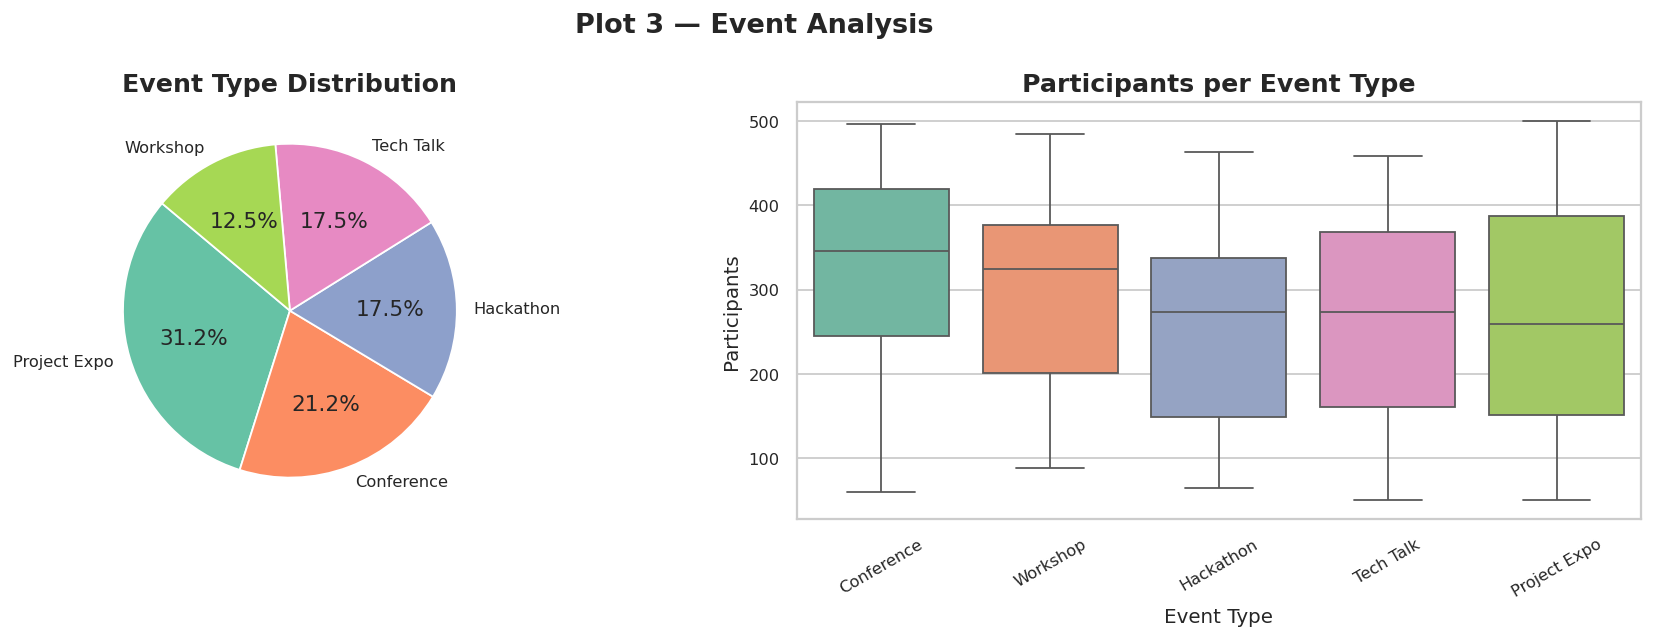

✅ Saved: plot3_event_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 3 — Event Analysis", fontsize=15, fontweight="bold")

# Pie — event type share
type_counts = events["event_type"].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(type_counts)),
            startangle=140, wedgeprops={"edgecolor": "white"})
axes[0].set_title("Event Type Distribution")

# Box — participants per event type
event_order = events.groupby("event_type")["participants"].median().sort_values(ascending=False).index
sns.boxplot(data=events, x="event_type", y="participants",
            order=event_order, palette="Set2", ax=axes[1])
axes[1].set_title("Participants per Event Type")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Participants")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("plot3_event_analysis.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot3_event_analysis.png")

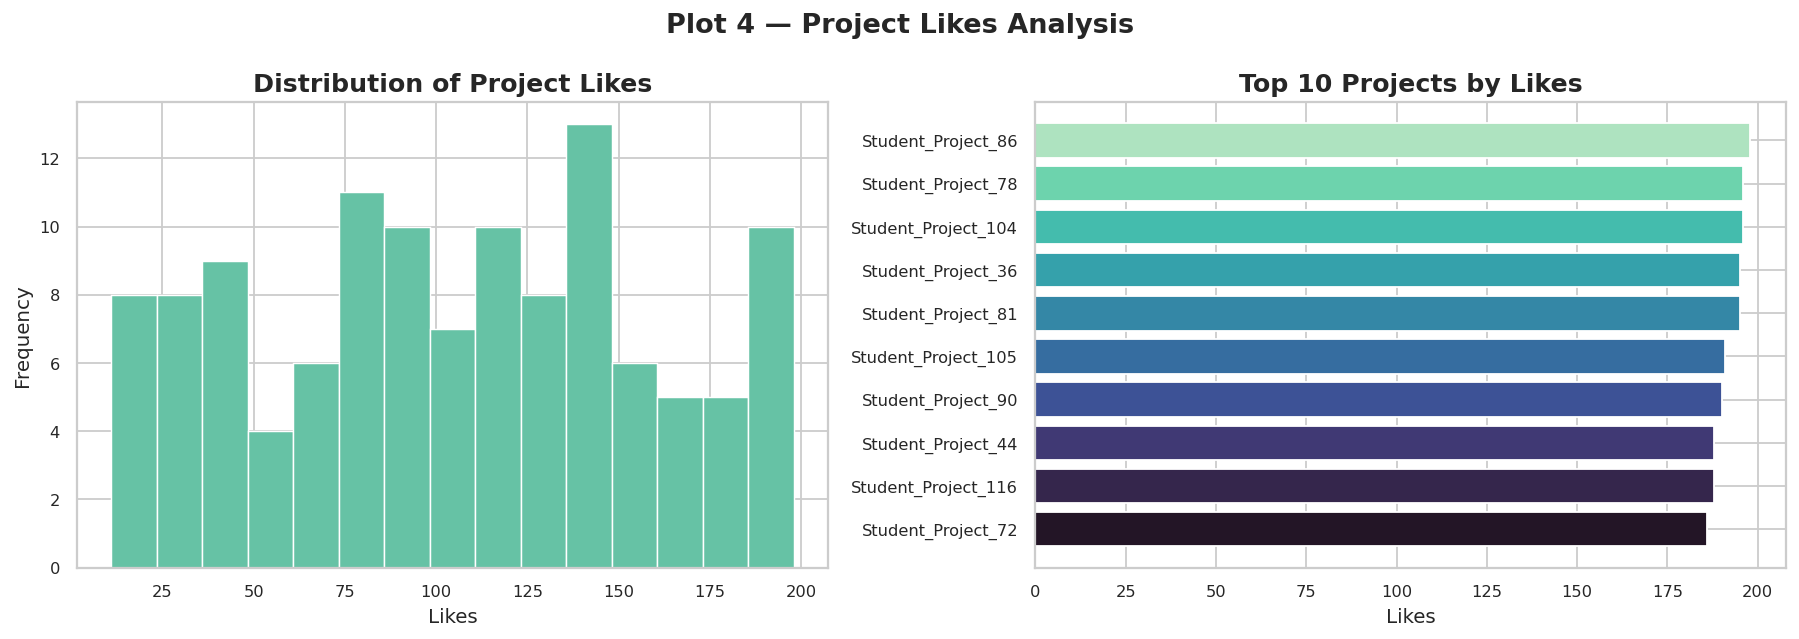

✅ Saved: plot4_project_likes.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 4 — Project Likes Analysis", fontsize=15, fontweight="bold")

# Histogram
axes[0].hist(projects["likes"], bins=15, color=PALETTE[0],
             edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribution of Project Likes")
axes[0].set_xlabel("Likes")
axes[0].set_ylabel("Frequency")

# Top 10 projects by likes
top_proj = projects.nlargest(10, "likes")[["project_title", "likes"]]
axes[1].barh(top_proj["project_title"], top_proj["likes"],
             color=sns.color_palette("mako_r", 10))
axes[1].set_title("Top 10 Projects by Likes")
axes[1].set_xlabel("Likes")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("plot4_project_likes.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot4_project_likes.png")

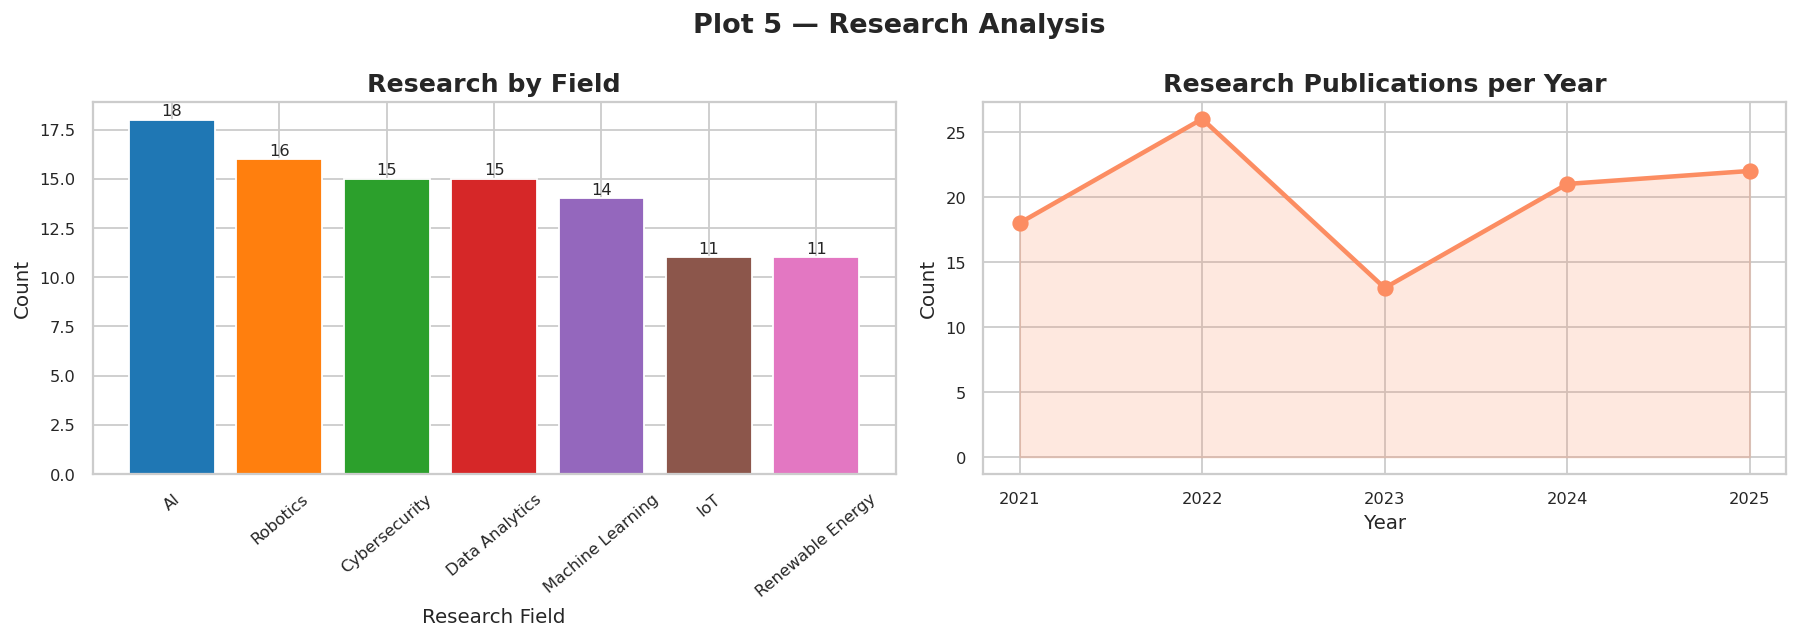

✅ Saved: plot5_research_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 5 — Research Analysis", fontsize=15, fontweight="bold")

# Field bar
field_counts = research["research_field"].value_counts()
axes[0].bar(field_counts.index, field_counts.values,
            color=sns.color_palette("tab10", len(field_counts)))
axes[0].set_title("Research by Field")
axes[0].set_xlabel("Research Field")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=40)
for i, v in enumerate(field_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontsize=9)

# Year line
year_trend = research["year"].value_counts().sort_index()
axes[1].plot(year_trend.index, year_trend.values, marker="o",
             color=PALETTE[1], linewidth=2.5, markersize=8)
axes[1].fill_between(year_trend.index, year_trend.values, alpha=0.2, color=PALETTE[1])
axes[1].set_title("Research Publications per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("plot5_research_analysis.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot5_research_analysis.png")

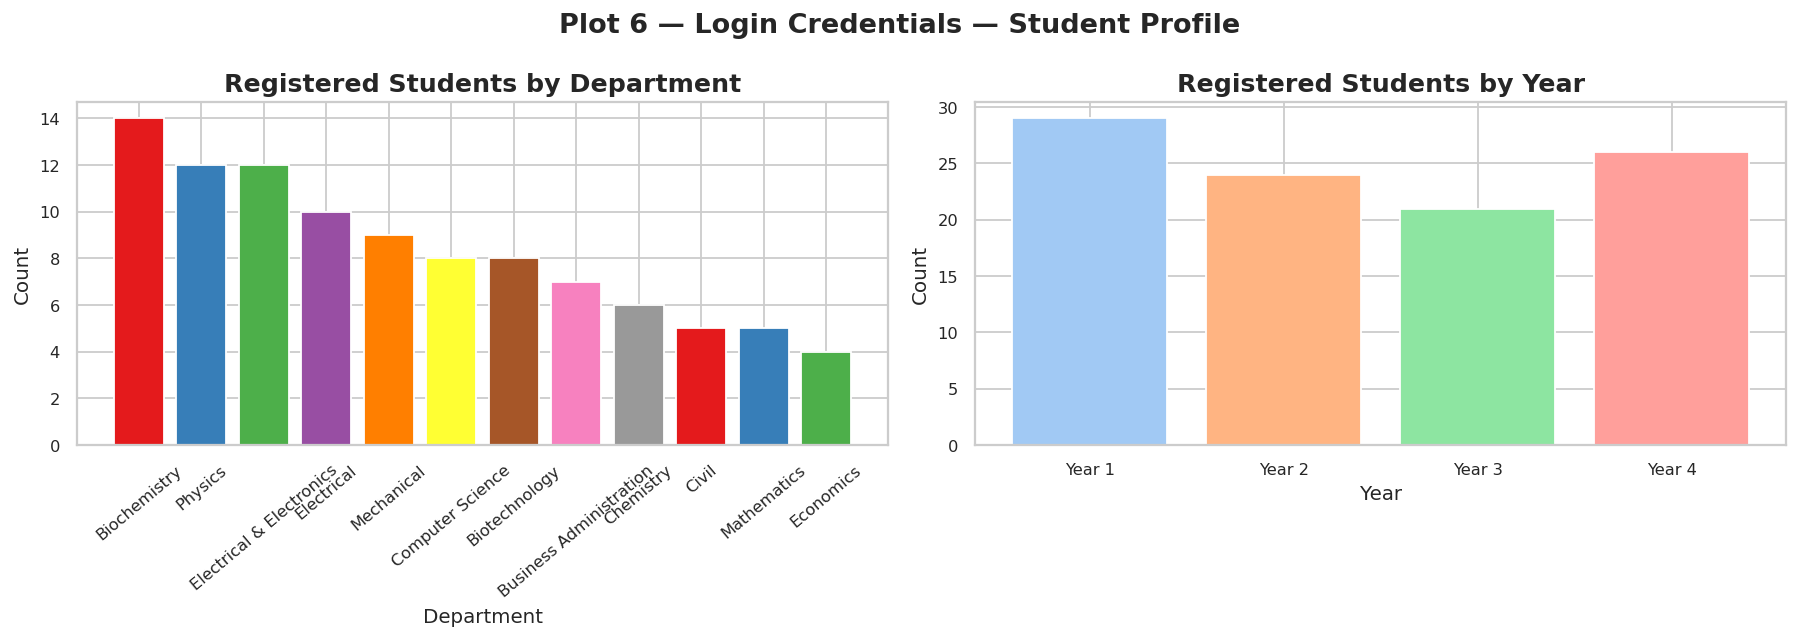

✅ Saved: plot6_login_profile.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 6 — Login Credentials — Student Profile", fontsize=15, fontweight="bold")

dept_login = login["department"].value_counts()
axes[0].bar(dept_login.index, dept_login.values,
            color=sns.color_palette("Set1", len(dept_login)))
axes[0].set_title("Registered Students by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=40)

year_login = login["year"].value_counts().sort_index()
axes[1].bar([f"Year {y}" for y in year_login.index], year_login.values,
            color=sns.color_palette("pastel", len(year_login)))
axes[1].set_title("Registered Students by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("plot6_login_profile.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot6_login_profile.png")

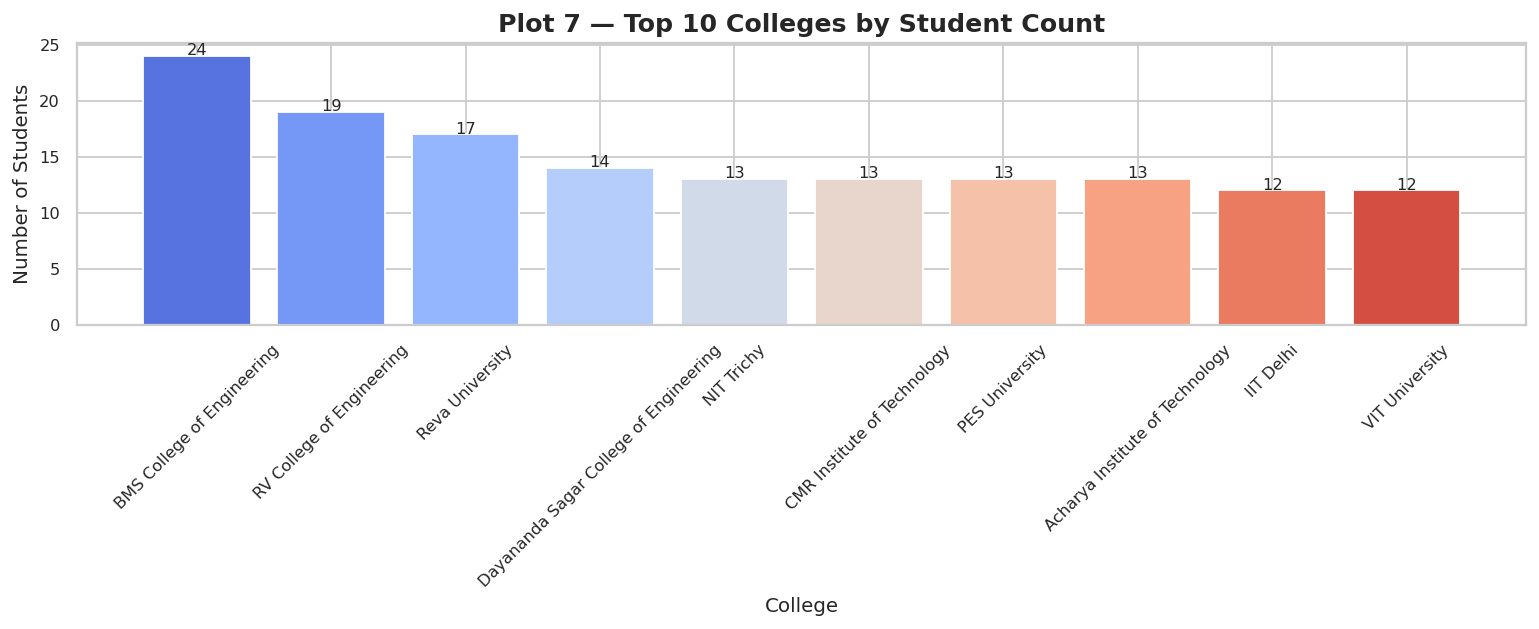

✅ Saved: plot7_students_per_college.png


In [ ]:
merged_sc = students.merge(colleges, on="college_id", how="left")
top_colleges = merged_sc["college_name"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_colleges.index, top_colleges.values,
              color=sns.color_palette("coolwarm", 10))
ax.set_title("Plot 7 — Top 10 Colleges by Student Count", fontsize=14, fontweight="bold")
ax.set_xlabel("College")
ax.set_ylabel("Number of Students")
ax.tick_params(axis="x", rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot7_students_per_college.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot7_students_per_college.png")

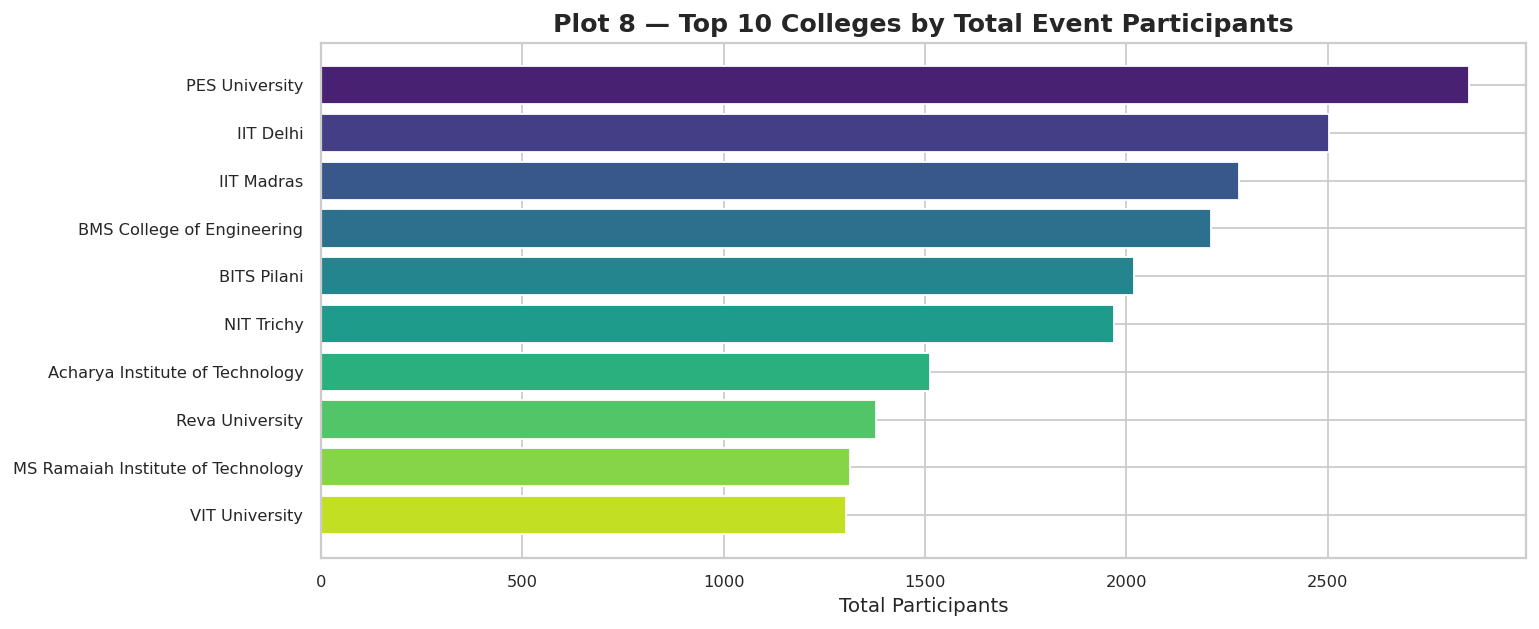

✅ Saved: plot8_event_participants_per_college.png


In [ ]:
merged_ec = events.merge(colleges, on="college_id", how="left")
events_per_college = merged_ec.groupby("college_name")["participants"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(events_per_college.index, events_per_college.values,
        color=sns.color_palette("viridis", 10))
ax.set_title("Plot 8 — Top 10 Colleges by Total Event Participants", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Participants")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plot8_event_participants_per_college.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot8_event_participants_per_college.png")

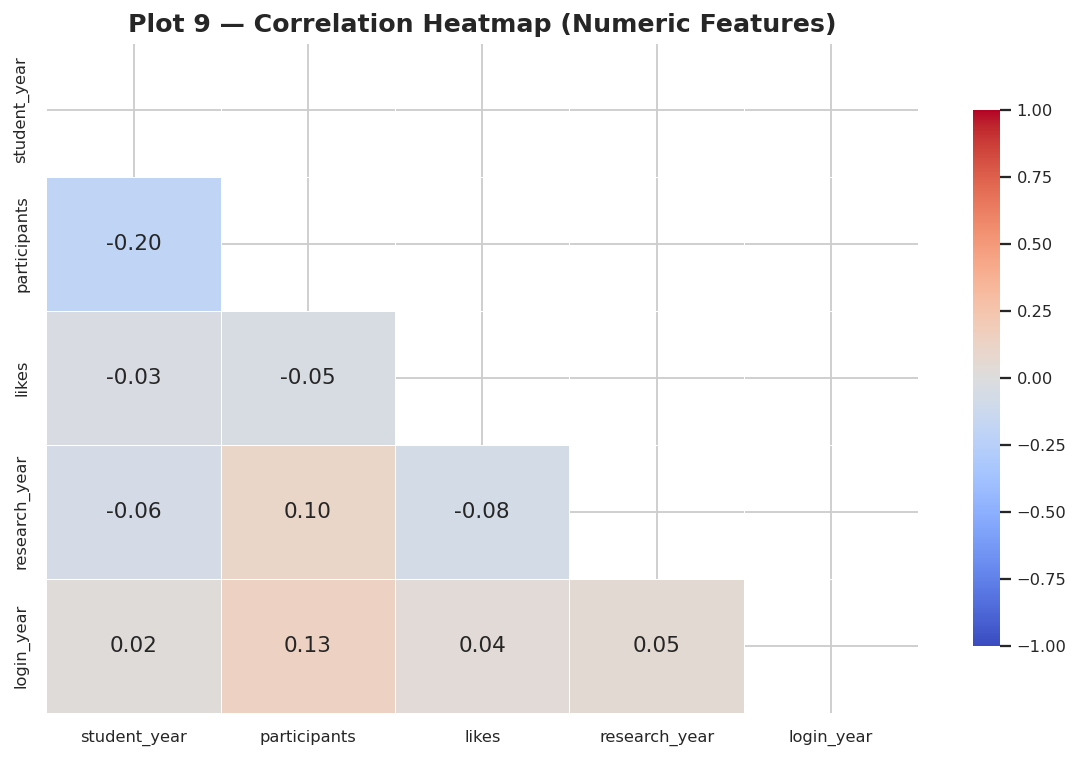

✅ Saved: plot9_correlation_heatmap.png


In [ ]:
num_df = pd.concat([
    students[["year"]].rename(columns={"year": "student_year"}),
    events[["participants"]],
    projects[["likes"]],
    research[["year"]].rename(columns={"year": "research_year"}),
    login[["year"]].rename(columns={"year": "login_year"}),
], axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
ax.set_title("Plot 9 — Correlation Heatmap (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot9_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot9_correlation_heatmap.png")

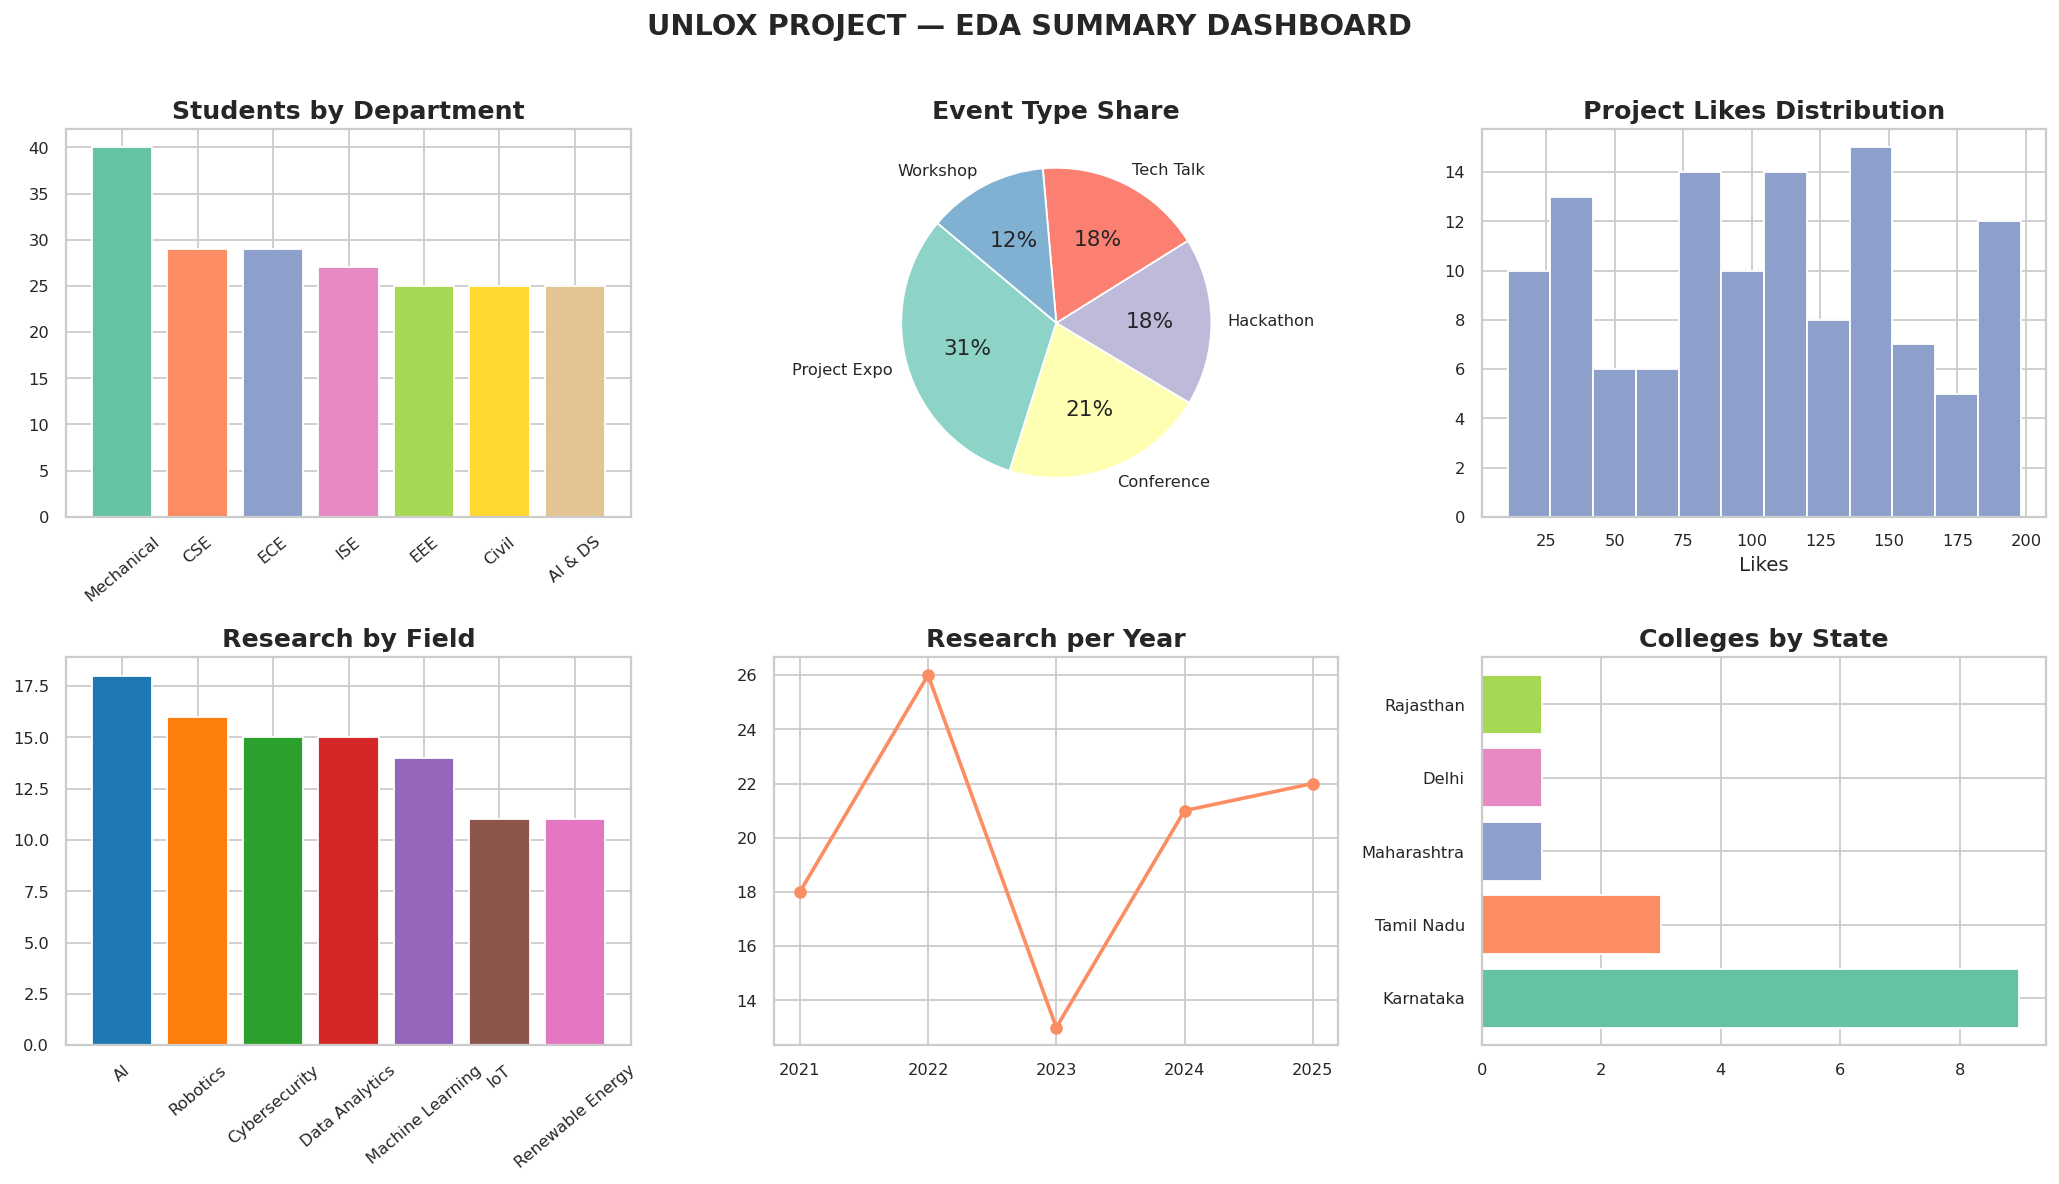

✅ Saved: plot10_summary_dashboard.png

  ✅ EDA COMPLETE — All 10 plots generated!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("UNLOX PROJECT — EDA SUMMARY DASHBOARD", fontsize=16, fontweight="bold", y=1.01)

# 1 - Students by dept
dept_counts = students["department"].value_counts()
axes[0][0].bar(dept_counts.index, dept_counts.values, color=PALETTE)
axes[0][0].set_title("Students by Department")
axes[0][0].tick_params(axis="x", rotation=40)

# 2 - Event type pie
axes[0][1].pie(type_counts.values, labels=type_counts.index, autopct="%1.0f%%",
               colors=sns.color_palette("Set3", len(type_counts)),
               startangle=140, wedgeprops={"edgecolor": "white"})
axes[0][1].set_title("Event Type Share")

# 3 - Likes histogram
axes[0][2].hist(projects["likes"], bins=12, color=PALETTE[2], edgecolor="white")
axes[0][2].set_title("Project Likes Distribution")
axes[0][2].set_xlabel("Likes")

# 4 - Research field
axes[1][0].bar(field_counts.index, field_counts.values,
               color=sns.color_palette("tab10", len(field_counts)))
axes[1][0].set_title("Research by Field")
axes[1][0].tick_params(axis="x", rotation=40)

# 5 - Year trend
axes[1][1].plot(year_trend.index, year_trend.values, marker="o",
                color=PALETTE[1], linewidth=2)
axes[1][1].set_title("Research per Year")
axes[1][1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 6 - Colleges by state
axes[1][2].barh(state_counts.index, state_counts.values,
                color=sns.color_palette("Set2", len(state_counts)))
axes[1][2].set_title("Colleges by State")

plt.tight_layout()
plt.savefig("plot10_summary_dashboard.png", bbox_inches="tight")
plt.show()
print("✅ Saved: plot10_summary_dashboard.png")


print("\n" + "=" * 55)
print("  ✅ EDA COMPLETE — All 10 plots generated!")
print("=" * 55)